In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


In [2]:
sales_df = pd.read_csv("outputs/sales_data.csv")
sales_df.head()


,Order_ID,Customer_ID,Product,Region,Quantity,Unit_Price,Order_Date,Revenue
0,1001,27,Accessories,West,5,60000,2024-01-01,300000
1,1002,17,Laptop,East,4,60000,2024-01-02,240000
2,1003,9,Tablet,North,5,15000,2024-01-03,75000
3,1004,33,Laptop,South,4,15000,2024-01-04,60000
4,1005,20,Accessories,South,5,8000,2024-01-05,40000


In [3]:
sales_df["Order_Date"] = pd.to_datetime(sales_df["Order_Date"], errors="coerce")

if "Revenue" not in sales_df.columns:
    sales_df["Revenue"] = sales_df["Quantity"] * sales_df["Unit_Price"]

sales_df[["Order_Date", "Revenue"]].head()


,Order_Date,Revenue
0,2024-01-01,300000
1,2024-01-02,240000
2,2024-01-03,75000
3,2024-01-04,60000
4,2024-01-05,40000


In [4]:
sales_df[["Order_Date", "Revenue"]].isnull().sum()


Order_Date    0
Revenue       0
dtype: int64

In [5]:
daily_sales = (sales_df
               .groupby("Order_Date", as_index=False)["Revenue"]
               .sum()
               .sort_values("Order_Date"))

daily_sales.head()


,Order_Date,Revenue
0,2024-01-01,300000
1,2024-01-02,240000
2,2024-01-03,75000
3,2024-01-04,60000
4,2024-01-05,40000


In [6]:
os.makedirs("outputs", exist_ok=True)
daily_sales.to_csv("outputs/daily_sales.csv", index=False)


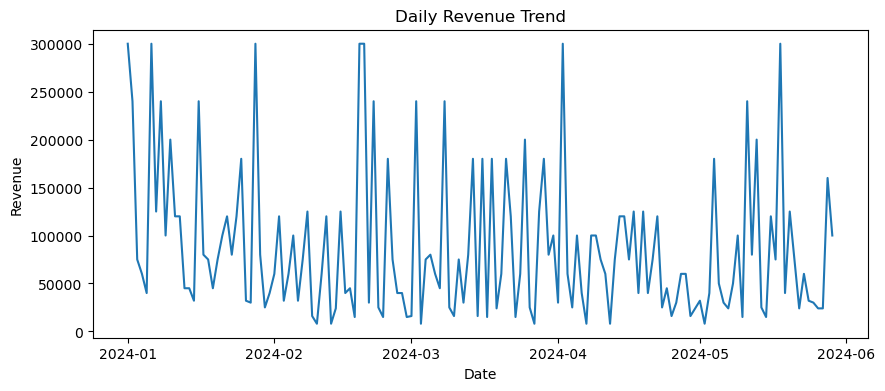

In [7]:
plt.figure(figsize=(10,4))
plt.plot(daily_sales["Order_Date"], daily_sales["Revenue"])
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()


In [8]:
daily_sales["Rolling_7"] = daily_sales["Revenue"].rolling(window=7, min_periods=1).mean()
daily_sales.head()


,Order_Date,Revenue,Rolling_7
0,2024-01-01,300000,300000.0
1,2024-01-02,240000,270000.0
2,2024-01-03,75000,205000.0
3,2024-01-04,60000,168750.0
4,2024-01-05,40000,143000.0


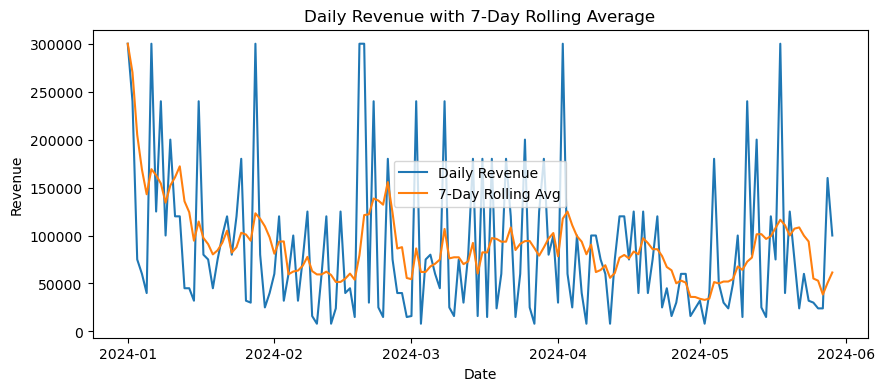

In [9]:
plt.figure(figsize=(10,4))
plt.plot(daily_sales["Order_Date"], daily_sales["Revenue"], label="Daily Revenue")
plt.plot(daily_sales["Order_Date"], daily_sales["Rolling_7"], label="7-Day Rolling Avg")
plt.title("Daily Revenue with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()


In [10]:
daily_sales = daily_sales.reset_index(drop=True)
split_idx = int(len(daily_sales) * 0.8)

train = daily_sales.iloc[:split_idx].copy()
test  = daily_sales.iloc[split_idx:].copy()

len(train), len(test)


(120, 30)

In [11]:
window = 7
ma_value = train["Revenue"].tail(window).mean()

test["Forecast_MA"] = ma_value
test[["Order_Date", "Revenue", "Forecast_MA"]].head()


,Order_Date,Revenue,Forecast_MA
120,2024-04-30,24000,36000.0
121,2024-05-01,32000,36000.0
122,2024-05-02,8000,36000.0
123,2024-05-03,40000,36000.0
124,2024-05-04,180000,36000.0


In [13]:
mae_ma = np.mean(np.abs(test["Revenue"] - test["Forecast_MA"]))
mae_ma


np.float64(51466.666666666664)

In [14]:
from sklearn.linear_model import LinearRegression

# Create time index feature
daily_sales["t"] = np.arange(len(daily_sales))

X_train = train.index.values.reshape(-1, 1)
y_train = train["Revenue"].values

X_test = test.index.values.reshape(-1, 1)
y_test = test["Revenue"].values

model = LinearRegression()
model.fit(X_train, y_train)

test["Forecast_LR"] = model.predict(X_test)
test[["Order_Date", "Revenue", "Forecast_LR"]].head()


,Order_Date,Revenue,Forecast_LR
120,2024-04-30,24000,61392.857143
121,2024-05-01,32000,60920.011806
122,2024-05-02,8000,60447.166470
123,2024-05-03,40000,59974.321133
124,2024-05-04,180000,59501.475797


In [15]:
mae_lr = np.mean(np.abs(test["Revenue"] - test["Forecast_LR"]))
mae_lr


np.float64(52562.71153089335)

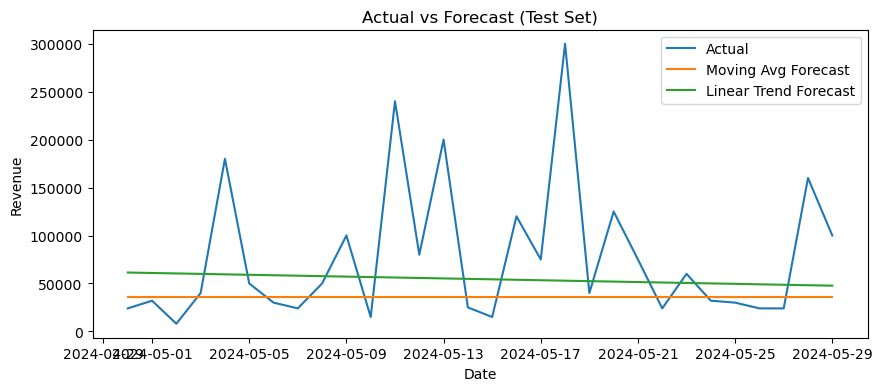

In [16]:
plt.figure(figsize=(10,4))
plt.plot(test["Order_Date"], test["Revenue"], label="Actual")
plt.plot(test["Order_Date"], test["Forecast_MA"], label="Moving Avg Forecast")
plt.plot(test["Order_Date"], test["Forecast_LR"], label="Linear Trend Forecast")
plt.title("Actual vs Forecast (Test Set)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()


In [17]:
best_method = "Moving Average" if mae_ma < mae_lr else "Linear Regression"
best_method, mae_ma, mae_lr


('Moving Average',
 np.float64(51466.666666666664),
 np.float64(52562.71153089335))

In [18]:
future_days = 7
last_date = daily_sales["Order_Date"].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=future_days)

if best_method == "Moving Average":
    future_forecast = np.array([ma_value] * future_days)
else:
    # continue the time index
    start_t = len(daily_sales)
    future_t = np.arange(start_t, start_t + future_days).reshape(-1, 1)
    future_forecast = model.predict(future_t)

future_df = pd.DataFrame({
    "Order_Date": future_dates,
    "Forecast_Revenue": future_forecast,
    "Method": best_method
})

future_df


,Order_Date,Forecast_Revenue,Method
0,2024-05-30,36000.0,Moving Average
1,2024-05-31,36000.0,Moving Average
2,2024-06-01,36000.0,Moving Average
3,2024-06-02,36000.0,Moving Average
4,2024-06-03,36000.0,Moving Average
5,2024-06-04,36000.0,Moving Average
6,2024-06-05,36000.0,Moving Average


In [19]:
# Save test forecasts + future forecasts
test_out = test[["Order_Date", "Revenue", "Forecast_MA", "Forecast_LR"]].copy()
test_out.to_csv("outputs/forecast_test.csv", index=False)

future_df.to_csv("outputs/forecast_next7days.csv", index=False)

print("Saved: outputs/daily_sales.csv, outputs/forecast_test.csv, outputs/forecast_next7days.csv")


Saved: outputs/daily_sales.csv, outputs/forecast_test.csv, outputs/forecast_next7days.csv


In [20]:
os.makedirs("outputs/plots", exist_ok=True)

# Trend plot
plt.figure(figsize=(10,4))
plt.plot(daily_sales["Order_Date"], daily_sales["Revenue"], label="Daily Revenue")
plt.plot(daily_sales["Order_Date"], daily_sales["Rolling_7"], label="7-Day Rolling Avg")
plt.title("Daily Revenue with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.savefig("outputs/plots/sales_trend.png", dpi=200, bbox_inches="tight")
plt.close()

# Forecast plot (test)
plt.figure(figsize=(10,4))
plt.plot(test["Order_Date"], test["Revenue"], label="Actual")
plt.plot(test["Order_Date"], test["Forecast_MA"], label="MA Forecast")
plt.plot(test["Order_Date"], test["Forecast_LR"], label="LR Forecast")
plt.title("Actual vs Forecast (Test Set)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.savefig("outputs/plots/forecast_vs_actual.png", dpi=200, bbox_inches="tight")
plt.close()

print("Saved plots in outputs/plots/")


Saved plots in outputs/plots/


In [22]:

print("MAE (Moving Average):", round(mae_ma, 2))
print("MAE (Linear Regression):", round(mae_lr, 2))
print("Best method chosen:", best_method)


MAE (Moving Average): 51466.67
MAE (Linear Regression): 52562.71
Best method chosen: Moving Average
